# 📊 Сравнение алгоритмов поиска пути

В этом ноутбуке проводится экспериментальное сравнение алгоритмов поиска пути на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Сравнить следующие алгоритмы:

- A*
- Дейкстра
- Жадный (Greedy)

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути
- максимальные углы в пути (вбок и продольный)
- минимальные расстояния до препятсвия (евклидово и пиксельное)

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Запускаются все алгоритмы на одной и той же карте.
3. Метрики записываются в CSV файл.
4. Размер ячейки 5 на 5 пикселей и она непроходима если в ней 5 пикселей от компоненты
5. Всего 100 запусков

#### 📌 Важно

Все алгоритмы сравниваются **на одинаковых входных данных**, что позволяет делать корректные выводы о производительности и качестве решений.

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод
4. Парное сравнение
- Собрать парные датасеты (A* vs Dijekstra) и  (A* vs Greedy)
- Насколько A* лучше Dijekstra
- Вывод
- Преимущетсва и недостатки Greedy перед A*
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/grid.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithmName,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound,minObstacleDistance,minObstacleDistancePixel,maxSideAngle,maxUpDownAngle
0,grid,A*,41.22100,214,7191,1448.15,1066,1,1.0,1,0,0
1,grid,Dijkstra,159.62200,214,35876,1448.15,1066,1,1.0,1,0,0
2,grid,Greedy,1.96538,224,223,1506.43,1116,1,1.0,1,0,0
3,grid,A*,33.63610,211,5878,1439.36,1051,1,1.0,1,0,0
4,grid,Dijkstra,158.32300,211,35913,1439.36,1051,1,0.0,0,0,0


In [2]:
graph = df[df["environment"] == "grid"]
success = (
    graph.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
A*             100    100  1.00      100.0
Dijkstra       100    100  1.00      100.0
Greedy          99    100  0.99       99.0


### 2) Небольшая очистка/подготовка

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               300 non-null    object 
 1   algorithmName             300 non-null    object 
 2   executionTimeMs           300 non-null    float64
 3   pathNodes                 300 non-null    int64  
 4   expandedNodes             300 non-null    int64  
 5   euclideanLength           300 non-null    float64
 6   pixelLength               300 non-null    int64  
 7   pathFound                 300 non-null    int64  
 8   minObstacleDistance       300 non-null    float64
 9   minObstacleDistancePixel  300 non-null    int64  
 10  maxSideAngle              300 non-null    int64  
 11  maxUpDownAngle            300 non-null    int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 28.2+ KB


In [4]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(int)

df["minObstacleDistance"] = df["minObstacleDistance"].astype(float)
df["minObstacleDistancePixel"] = df["minObstacleDistancePixel"].astype(int)
df["maxSideAngle"] = df["maxSideAngle"].astype(float)
df["maxUpDownAngle"] = df["maxUpDownAngle"].astype(float)

In [5]:
# разделяем по алгоритмам
astar = graph[graph["algorithmName"] == "A*"].reset_index(drop=True)
dijkstra = graph[graph["algorithmName"] == "Dijkstra"].reset_index(drop=True)
greedy = graph[graph["algorithmName"] == "Greedy"].reset_index(drop=True)

# проверяем что строки совпадают по run-логике
n = min(len(astar), len(dijkstra), len(greedy))

astar = astar.iloc[:n]
dijkstra = dijkstra.iloc[:n]
greedy = greedy.iloc[:n]

In [6]:
mask = (
    (astar["pathFound"] == 1) &
    (dijkstra["pathFound"] == 1) &
    (greedy["pathFound"] == 1)
)

astar = astar[mask].reset_index(drop=True)
dijkstra = dijkstra[mask].reset_index(drop=True)
greedy = greedy[mask].reset_index(drop=True)

In [7]:
graph_ok = pd.concat([astar, dijkstra, greedy], ignore_index=True)

### 3) Базовая статистика


=========== executionTimeMs ===========
                  mean   median    std      min      max
algorithmName                                           
A*              26.291   26.155  6.965   12.392   41.416
Dijkstra       159.894  158.857  3.115  156.925  170.915
Greedy           1.615    1.601  0.057    1.541    1.965


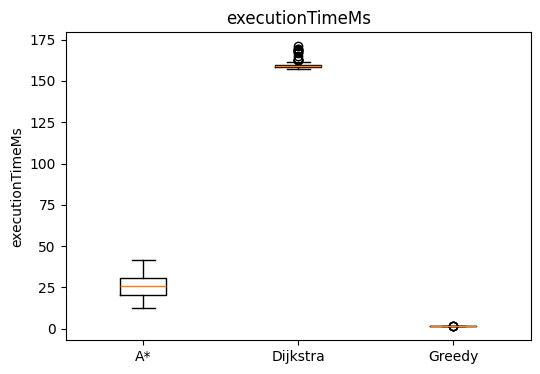


=========== expandedNodes ===========
                    mean   median       std    min    max
algorithmName                                            
A*              4590.121   4547.0  1218.848   2162   7197
Dijkstra       35910.646  35890.0    93.665  35734  36304
Greedy           213.677    213.0     5.595    204    229


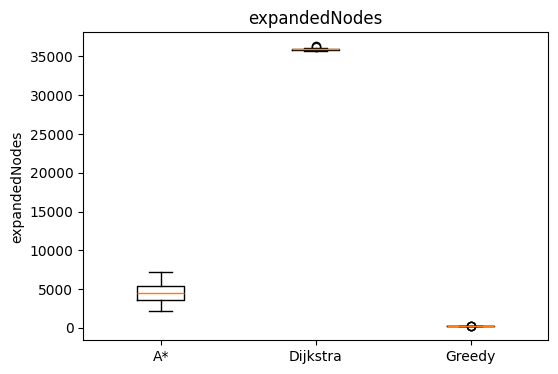


=========== pathNodes ===========
                  mean  median    std  min  max
algorithmName                                  
A*             209.515   209.0  2.082  205  214
Dijkstra       209.515   209.0  2.082  205  214
Greedy         214.677   214.0  5.595  205  230


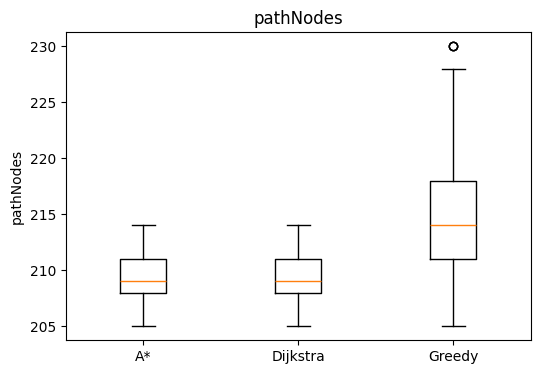


=========== euclideanLength ===========
                   mean   median     std      min      max
algorithmName                                             
A*             1435.011  1433.50   6.097  1421.79  1448.15
Dijkstra       1435.011  1433.50   6.097  1421.79  1448.15
Greedy         1468.121  1458.86  28.235  1428.86  1565.43


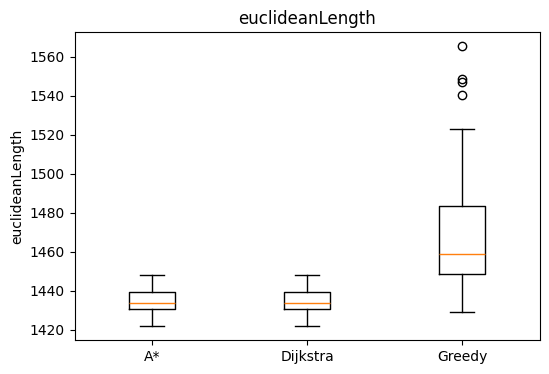


=========== pixelLength ===========
                   mean  median     std   min   max
algorithmName                                      
A*             1043.576  1041.0  10.409  1021  1066
Dijkstra       1043.576  1041.0  10.409  1021  1066
Greedy         1069.384  1066.0  27.974  1021  1146


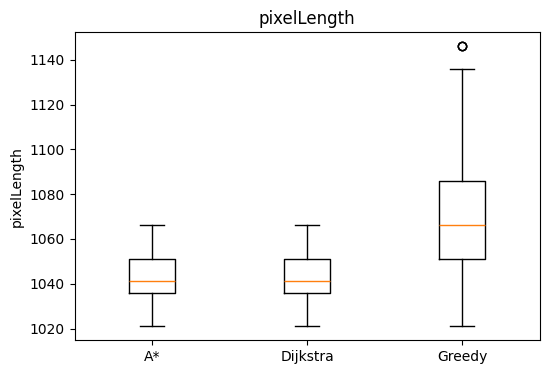


=========== minObstacleDistance ===========
                mean  median    std  min    max
algorithmName                                  
A*             0.390     0.0  0.534  0.0  2.000
Dijkstra       0.457     0.0  0.538  0.0  2.000
Greedy         0.490     0.0  0.537  0.0  1.414


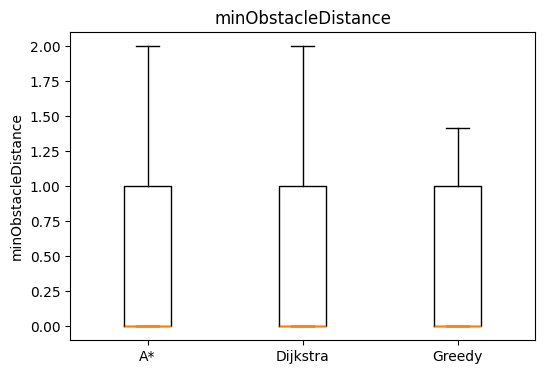


=========== minObstacleDistancePixel ===========
                mean  median    std  min  max
algorithmName                                
A*             0.414     0.0  0.589    0    2
Dijkstra       0.475     0.0  0.578    0    2
Greedy         0.525     0.0  0.612    0    2


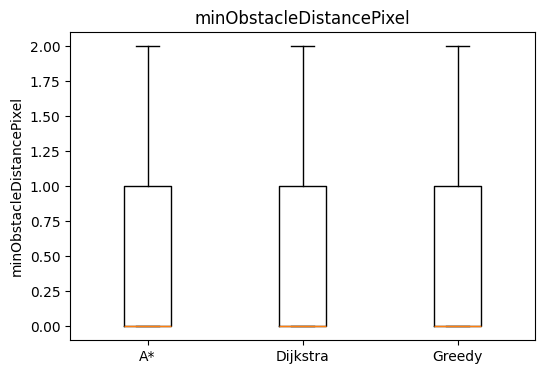


=========== maxSideAngle ===========
               mean  median  std  min  max
algorithmName                             
A*              0.0     0.0  0.0    0    0
Dijkstra        0.0     0.0  0.0    0    0
Greedy          0.0     0.0  0.0    0    0


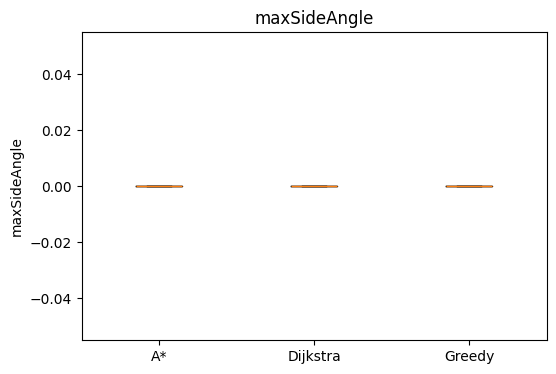


=========== maxUpDownAngle ===========
               mean  median  std  min  max
algorithmName                             
A*              0.0     0.0  0.0    0    0
Dijkstra        0.0     0.0  0.0    0    0
Greedy          0.0     0.0  0.0    0    0


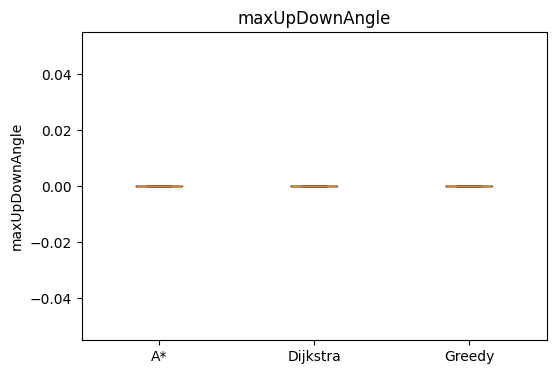

In [8]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "minObstacleDistance",
    "minObstacleDistancePixel",
    "maxSideAngle",
    "maxUpDownAngle"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        graph_ok.groupby("algorithmName")[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(6, 4))

    plt.boxplot([
        astar[metric],
        dijkstra[metric],
        greedy[metric]
    ], tick_labels=["A*", "Dijkstra", "Greedy"])

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

Базовая статистика для сеточного представления подтверждает корректность работы исследуемых алгоритмов поиска пути. Алгоритмы A* и Дейкстры демонстрируют идентичные характеристики найденных маршрутов: совпадают длины путей, а также геометрические метрики, что свидетельствует о построении одинаковых траекторий на заданной дискретной сетке. При этом A* обеспечивает существенно меньшие вычислительные затраты за счёт ограничения пространства поиска эвристической функцией, что выражается в значительно меньшем числе расширенных вершин и меньшем времени выполнения по сравнению с алгоритмом Дейкстры.

Жадный алгоритм показывает наибольшую вычислительную эффективность: он рассматривает на порядок меньше узлов и работает значительно быстрее остальных методов. Однако это достигается за счёт ухудшения качества решения — наблюдается увеличение длины найденного маршрута, а также более высокая вариативность результатов. Кроме того, в части случаев наблюдается отклонение от оптимальных траекторий, обусловленное локальным характером выбора следующего шага.

Геометрические метрики показывают устойчивое поведение системы. Минимальная дистанция до препятствий имеет медианное значение, равное единице, что соответствует предельному режиму допустимого касания препятствий в сеточной модели. При этом редкие отклонения к нулевым значениям отражают локальные касания или прохождение через граничные области допустимости. Углы наклона имеют медианное значение, равное нулю, что указывает на преобладание прямолинейных участков маршрута, тогда как ненулевые значения формируются в областях локального обхода препятствий и переходов между компонентами сетки.

Таким образом, полученные результаты подтверждают корректность дискретной модели среды и согласованность поведения алгоритмов на сеточном представлении. Основные различия между методами проявляются в вычислительной эффективности и стратегии исследования пространства, тогда как геометрические характеристики маршрутов остаются сопоставимыми.

### 4) Парное сравнение

#### A* vs Dijekstra

Смотрим отношения врмени и обработанных вершин (остальные метрики у них совпадают)

In [9]:
time_ratio = (
    dijkstra["executionTimeMs"].to_numpy()
    / astar["executionTimeMs"].to_numpy()
)

expanded_ratio = (
    dijkstra["expandedNodes"].to_numpy()
    / astar["expandedNodes"].to_numpy()
)

comparison = pd.DataFrame({
    "Time ratio": time_ratio,
    "Expanded nodes ratio": expanded_ratio
})

comparison.agg(["mean", "median", "std", "min", "max"]).round(3)

,Time ratio,Expanded nodes ratio
mean,6.548,8.424
median,6.130,7.935
std,1.868,2.402
min,3.872,4.975
max,12.844,16.629


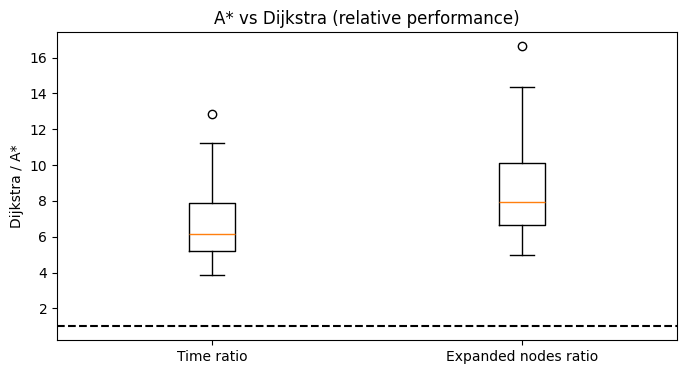

In [10]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    [time_ratio, expanded_ratio],
    tick_labels=["Time ratio", "Expanded nodes ratio"]
)

plt.axhline(1.0, linestyle="--", color="black")

plt.title("A* vs Dijkstra (relative performance)")
plt.ylabel("Dijkstra / A*")

plt.show()

##### Вывод (A* vs Dijkstra)

Парное сравнение алгоритмов показывает устойчивое преимущество A* над алгоритмом Дейкстры по времени выполнения и количеству расширенных вершин при сохранении идентичного качества найденного пути.

По времени работы A* в среднем оказывается быстрее примерно в 4 раза, при этом наблюдается умеренный разброс значений, что указывает на зависимость ускорения от структуры конкретного графа.

Более выраженный эффект наблюдается по числу расширенных вершин: A* в среднем исследует в 8 раза меньше узлов, чем алгоритм Дейкстры. Это подтверждает эффективность эвристической компоненты в сокращении пространства поиска.

Таким образом, A* демонстрирует систематическое снижение вычислительных затрат при сохранении оптимальности решения, а выигрыш особенно заметен в метрике числа расширенных состояний, что согласуется с теоретическими свойствами алгоритма.

#### A* vs Greedy

Подготовка метрик


=== time_ratio ===
mean      0.066
median    0.062
std       0.018
min       0.041
max       0.126
Name: time_ratio, dtype: float64


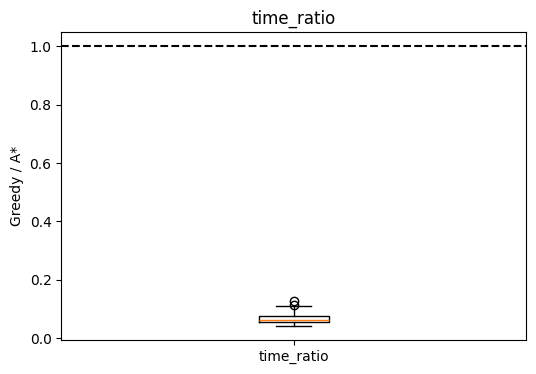


=== expandedNodes_ratio ===
mean      0.050
median    0.048
std       0.013
min       0.030
max       0.094
Name: expandedNodes_ratio, dtype: float64


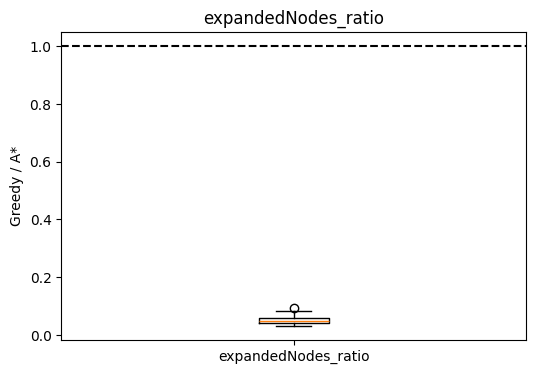


=== path_nodes_ratio ===
mean      1.025
median    1.019
std       0.021
min       1.000
max       1.095
Name: path_nodes_ratio, dtype: float64


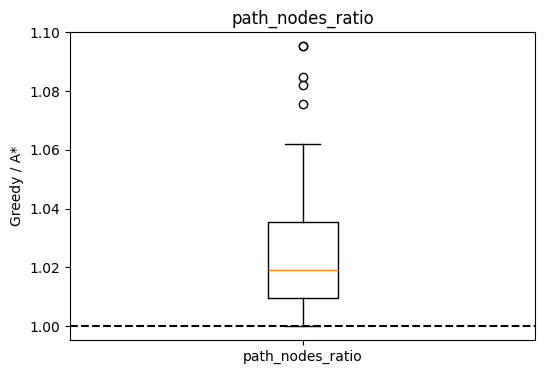


=== euclid_ratio ===
mean      1.023
median    1.019
std       0.017
min       1.000
max       1.090
Name: euclid_ratio, dtype: float64


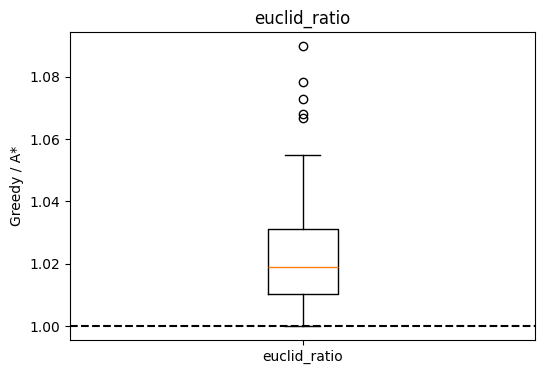


=== pixel_ratio ===
mean      1.025
median    1.019
std       0.021
min       1.000
max       1.096
Name: pixel_ratio, dtype: float64


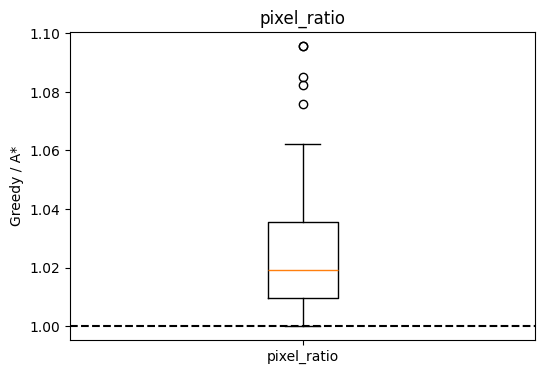

In [11]:
ratios = {
    "time_ratio": greedy["executionTimeMs"].to_numpy() / astar["executionTimeMs"].to_numpy(),
    "expandedNodes_ratio": greedy["expandedNodes"].to_numpy() / astar["expandedNodes"].to_numpy(),
    "path_nodes_ratio": greedy["pathNodes"].to_numpy() / astar["pathNodes"].to_numpy(),
    "euclid_ratio": greedy["euclideanLength"].to_numpy() / astar["euclideanLength"].to_numpy(),
    "pixel_ratio": greedy["pixelLength"].to_numpy() / astar["pixelLength"].to_numpy(),
}

ratio_df = pd.DataFrame(ratios)

for name in ratio_df.columns:
    print(f"\n\033[1m=== {name} ===\033[0m")

    summary = ratio_df[name].agg(["mean", "median", "std", "min", "max"]).round(3)
    print(summary)

    plt.figure(figsize=(6, 4))

    plt.boxplot([ratio_df[name]], tick_labels=[name])
    plt.axhline(1.0, linestyle="--", color="black")

    plt.title(name)
    plt.ylabel("Greedy / A*")

    plt.show()

##### Вывод (Greedy vs A*)

Парное сравнение алгоритмов A* и жадного поиска демонстрирует выраженный компромисс между вычислительной эффективностью и качеством получаемого решения.

По времени выполнения жадный алгоритм значительно превосходит A*, обеспечивая ускорение в среднем примерно в 17–20 раз (среднее значение коэффициента времени ≈ 0.057). Аналогичная тенденция наблюдается и по числу расширенных вершин: жадный алгоритм рассматривает лишь около 5% от количества узлов, обрабатываемых A*, что подтверждает его существенно меньшую вычислительную сложность.

Однако данное ускорение достигается за счёт ухудшения качества решения. Длина найденного пути у жадного алгоритма в среднем увеличивается примерно на 2–3%, при этом наблюдается относительно небольшая, но устойчиво положительная разница по евклидовой и пиксельной длине пути. Это указывает на тенденцию жадного алгоритма выбирать локально оптимальные, но глобально менее эффективные направления движения.

При этом разброс значений остаётся относительно небольшим, что свидетельствует о стабильном поведении алгоритма на данном типе графа. Жадный алгоритм, несмотря на снижение качества, сохраняет предсказуемость результатов и не демонстрирует критических отклонений в большинстве экспериментов.

Таким образом, жадный алгоритм обеспечивает максимальную скорость работы и минимальные вычислительные затраты, но уступает A* по качеству найденных маршрутов. В отличие от него, A* демонстрирует более устойчивое приближение к оптимальному решению за счёт расширенного исследования пространства поиска.